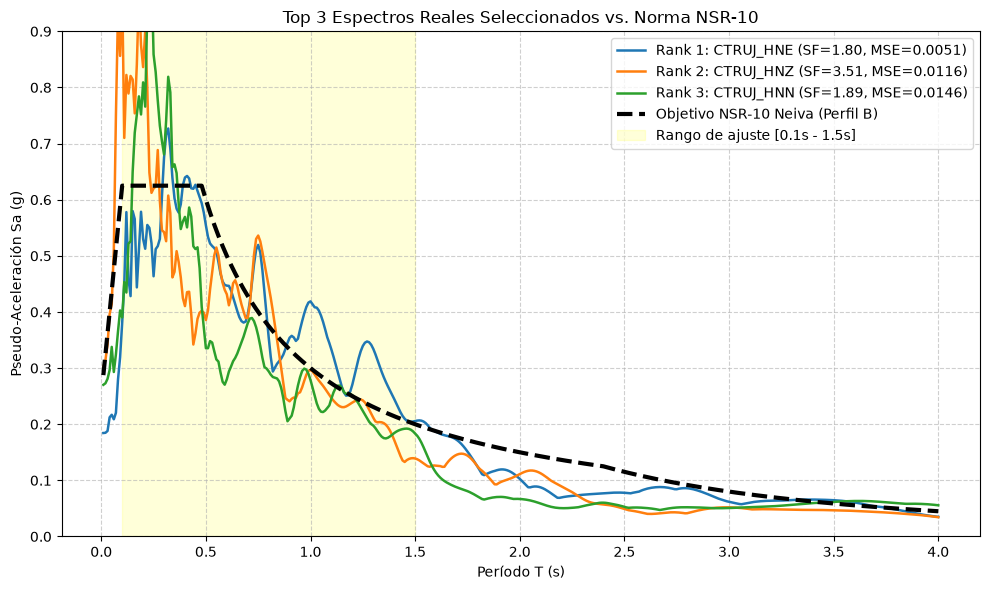


SELECCIÓN DE LOS 3 MEJORES REGISTROS REALES INDIVIDUALES
 Ranking ID_Registro  Factor_Escala_SF  Error_MSE  PGA_Final_g              Archivo_Guardado
       1   CTRUJ_HNE             1.800    0.00506        0.184 SismoReal_Rank1_CTRUJ_HNE.csv
       2   CTRUJ_HNZ             3.508    0.01155        0.300 SismoReal_Rank2_CTRUJ_HNZ.csv
       3   CTRUJ_HNN             1.890    0.01463        0.269 SismoReal_Rank3_CTRUJ_HNN.csv


In [1]:
import os
import obspy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =============================================================================
# 1. CONFIGURACIÓN Y CRITERIOS DE SELECCIÓN INDIVIDUAL
# =============================================================================
ruta_mseed = r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos originales\SGCWaveForm.mseed"
dir_salida = r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos sismo\sismos_seleccionados"

os.makedirs(dir_salida, exist_ok=True)

# Estaciones candidatas en roca
estaciones_roca = ["CTRUJ", "PAL", "URE", "RUS", "POP", "ROSC"]

# Rango de períodos de interés para la estructura / suelo
T_MIN_PEER, T_MAX_PEER = 0.1, 1.5

# Límites permitidos para el Factor de Escala (SF)
SF_MIN, SF_MAX = 0.25, 4.0

# Número de sismos reales individuales a seleccionar (p. ej., los 3 mejores)
NUM_SISMOS_A_SELECCIONAR = 3

# =============================================================================
# 2. FUNCIONES MATEMÁTICAS Y ESPECTRALES
# =============================================================================
def normalizar_aceleracion_a_g(tr):
    """Convierte amplitudes a unidades de 'g'."""
    datos = tr.data.astype(float)
    pga_raw = np.max(np.abs(datos))

    if pga_raw > 1000.0:
        acc_g = (datos / 400000.0) / 9.81
    elif pga_raw > 20.0:
        acc_g = (datos / 100.0) / 9.81
    elif pga_raw > 1.5:
        acc_g = datos / 9.81
    else:
        acc_g = datos

    return acc_g


def espectro_nsr10_neiva_roca(periodos, I=1.0):
    """Espectro elástico de diseño NSR-10 Neiva (Perfil B)."""
    Aa, Av = 0.25, 0.25
    Fa, Fv = 1.0, 1.0

    T0 = 0.1 * (Av * Fv) / (Aa * Fa)
    TC = 0.48 * (Av * Fv) / (Aa * Fa)
    TL = 2.4 * Fv

    Sa_norma = np.zeros(len(periodos))
    for idx, T in enumerate(periodos):
        if T < T0:
            Sa_norma[idx] = Aa * Fa * I * (1.0 + 1.5 * (T / T0))
        elif T0 <= T <= TC:
            Sa_norma[idx] = 2.5 * Aa * Fa * I
        elif TC < T <= TL:
            Sa_norma[idx] = (1.2 * Av * Fv * I) / T
        else:
            Sa_norma[idx] = (1.2 * Av * Fv * TL * I) / (T**2)

    return Sa_norma


def calcular_espectro_newmark(acc_g, dt, periodos, damping=0.05):
    """Integración de Newmark-Beta para obtener el espectro de respuestas Sa (g)."""
    acc_m_s2 = acc_g * 9.81
    Sa_g = np.zeros(len(periodos))
    gamma, beta = 0.5, 0.25
    N = len(acc_m_s2)

    for idx, T in enumerate(periodos):
        if T <= 0:
            Sa_g[idx] = np.max(np.abs(acc_g))
            continue
            
        omega = 2.0 * np.pi / T
        m = 1.0
        c = 2.0 * damping * omega * m
        k = (omega ** 2) * m

        k_hat = k + (gamma / (beta * dt)) * c + (1.0 / (beta * dt**2)) * m
        a_const = (1.0 / (beta * dt)) * m + (gamma / beta) * c
        b_const = (1.0 / (2.0 * beta)) * m + dt * ((gamma / (2.0 * beta)) - 1.0) * c

        u, v, a_rel = np.zeros(N), np.zeros(N), np.zeros(N)
        a_rel[0] = -acc_m_s2[0]

        for i in range(N - 1):
            df = -m * (acc_m_s2[i+1] - acc_m_s2[i]) + a_const * v[i] + b_const * a_rel[i]
            du = df / k_hat
            dv = (gamma / (beta * dt)) * du - (gamma / beta) * v[i] + dt * (1.0 - gamma / (2.0 * beta)) * a_rel[i]
            da = (1.0 / (beta * dt**2)) * du - (1.0 / (beta * dt)) * v[i] - (1.0 / (2.0 * beta)) * a_rel[i]

            u[i+1] = u[i] + du
            v[i+1] = v[i] + dv
            a_rel[i+1] = a_rel[i] + da

        Sa_m_s2 = (omega ** 2) * np.max(np.abs(u))
        Sa_g[idx] = Sa_m_s2 / 9.81

    return Sa_g


def calcular_mse_y_sf(Sa_real, Sa_objetivo, periodos, T_min, T_max):
    """Calcula el factor de escala óptimo SF y el Error Cuadrático Medio (MSE)."""
    mask = (periodos >= T_min) & (periodos <= T_max)
    Sa_r = Sa_real[mask]
    Sa_o = Sa_objetivo[mask]

    # Factor de escala por mínimos cuadrados
    SF = np.sum(Sa_o * Sa_r) / np.sum(Sa_r**2)
    
    # Espectro ajustado individual
    Sa_escalado = Sa_real * SF

    # Error cuadrático medio respecto a la norma
    mse = np.mean((Sa_escalado[mask] - Sa_o)**2)

    return SF, mse

# =============================================================================
# 3. EVALUACIÓN Y RANKING DE REGISTROS REALES
# =============================================================================
st = obspy.read(ruta_mseed)
st_roca = obspy.Stream([tr for tr in st if tr.stats.station in estaciones_roca and tr.stats.channel.startswith("HN")])

periodos = np.linspace(0.01, 4.0, 400)
Sa_target = espectro_nsr10_neiva_roca(periodos)

registros_evaluados = []

for tr in st_roca:
    estacion, canal = tr.stats.station, tr.stats.channel
    id_traza = f"{estacion}_{canal}"

    # Acondicionamiento de señal
    tr_proc = tr.copy()
    tr_proc.detrend("linear")
    tr_proc.filter("bandpass", freqmin=0.1, freqmax=25.0, corners=4, zerophase=True)

    dt = tr_proc.stats.delta
    acc_g_orig = normalizar_aceleracion_a_g(tr_proc)
    tiempo = np.arange(len(acc_g_orig)) * dt

    # Espectro real sin escalar
    Sa_real = calcular_espectro_newmark(acc_g_orig, dt, periodos)

    # Evaluación de ajuste (SF y MSE)
    SF, mse = calcular_mse_y_sf(Sa_real, Sa_target, periodos, T_MIN_PEER, T_MAX_PEER)

    # Filtrar solo registros con factor de escala razonable
    if SF_MIN <= SF <= SF_MAX:
        registros_evaluados.append({
            "id_traza": id_traza,
            "estacion": estacion,
            "canal": canal,
            "dt": dt,
            "tiempo": tiempo,
            "acc_g_orig": acc_g_orig,
            "acc_g_escalada": acc_g_orig * SF,
            "Sa_escalado": Sa_real * SF,
            "SF": SF,
            "MSE": mse,
            "PGA_escalado_g": np.max(np.abs(acc_g_orig * SF))
        })

# Ordenar por menor error MSE (ranking de mejor ajuste a peor)
registros_evaluados = sorted(registros_evaluados, key=lambda x: x["MSE"])

# Seleccionar los top N sismos reales
sismos_seleccionados = registros_evaluados[:NUM_SISMOS_A_SELECCIONAR]

# =============================================================================
# 4. EXPORTACIÓN Y GRAFICACIÓN DE LOS SISMOS SELECCIONADOS
# =============================================================================
plt.figure(figsize=(10, 6))
resumen_exportacion = []

for idx, sismo in enumerate(sismos_seleccionados, 1):
    id_traza = sismo["id_traza"]
    
    # 1. Exportar el Acelerograma Real Escalado individual (formato ejecutable para software geotécnico)
    df_acelerograma = pd.DataFrame({
        "Tiempo_s": sismo["tiempo"],
        "Aceleracion_g": sismo["acc_g_escalada"]
    })
    archivo_acc = os.path.join(dir_salida, f"SismoReal_Rank{idx}_{id_traza}.csv")
    df_acelerograma.to_csv(archivo_acc, index=False)

    # 2. Graficar espectro real individual
    plt.plot(periodos, sismo["Sa_escalado"], lw=1.8, 
             label=f"Rank {idx}: {id_traza} (SF={sismo['SF']:.2f}, MSE={sismo['MSE']:.4f})")

    resumen_exportacion.append({
        "Ranking": idx,
        "ID_Registro": id_traza,
        "Factor_Escala_SF": round(sismo["SF"], 3),
        "Error_MSE": round(sismo["MSE"], 5),
        "PGA_Final_g": round(sismo["PGA_escalado_g"], 3),
        "Archivo_Guardado": os.path.basename(archivo_acc)
    })

# Superponer espectro de norma NSR-10 Neiva
plt.plot(periodos, Sa_target, color="black", lw=3.0, linestyle="--", label="Objetivo NSR-10 Neiva (Perfil B)")
plt.axvspan(T_MIN_PEER, T_MAX_PEER, color='yellow', alpha=0.15, label=f"Rango de ajuste [{T_MIN_PEER}s - {T_MAX_PEER}s]")

plt.title(f"Top {NUM_SISMOS_A_SELECCIONAR} Espectros Reales Seleccionados vs. Norma NSR-10")
plt.xlabel("Período T (s)")
plt.ylabel("Pseudo-Aceleración Sa (g)")
plt.ylim(0, 0.9)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()

plt.savefig(os.path.join(dir_salida, "Top_Sismos_Reales_Seleccionados.png"), dpi=300)
plt.show()

# Reporte final por pantalla
df_reporte = pd.DataFrame(resumen_exportacion)
df_reporte.to_csv(os.path.join(dir_salida, "Reporte_Sismos_Seleccionados.csv"), index=False)

print("\n" + "="*85)
print(f"SELECCIÓN DE LOS {NUM_SISMOS_A_SELECCIONAR} MEJORES REGISTROS REALES INDIVIDUALES")
print("="*85)
print(df_reporte.to_string(index=False))

In [4]:
import os
import obspy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from obspy.clients.fdsn import Client
from geopy.distance import geodesic # Para distancias geodésicas automáticas

# =============================================================================
# 1. CARGA AUTOMÁTICA Y EXTRACTOR DE CABECERAS DEL ARCHIVO .MSEED
# =============================================================================
ruta_mseed = r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos originales\SGCWaveForm.mseed"
dir_salida = r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos sismo\sismos_dinamicos"

os.makedirs(dir_salida, exist_ok=True)

st = obspy.read(ruta_mseed)

# Extraer automáticamente la fecha/hora de inicio del sismo desde la primera traza
t_inicio_sismo = st[0].stats.starttime
t_fin_sismo = st[0].stats.endtime

print(f"Archivo cargado correctamente. Registros desde {t_inicio_sismo} hasta {t_fin_sismo}")

# =============================================================================
# 2. CONSULTA AUTOMÁTICA A SERVICIOS WEB (FDSN / IRIS / SGC)
# =============================================================================
# Se conectará dinámicamente a la base de datos sísmica global para buscar el evento
client = Client("IRIS") 

try:
    # Busca automáticamente el sismo correspondiente a la ventana de tiempo del .mseed
    cat = client.get_events(starttime=t_inicio_sismo - 300, endtime=t_fin_sismo + 300, minmagnitude=4.5)
    evento = cat[0]
    origen = evento.origins[0]
    magnitud = evento.magnitudes[0].mag
    lat_epi = origen.latitude
    lon_epi = origen.longitude
    profundidad_km = origen.depth / 1000.0
    nombre_evento = evento.event_descriptions[0].text if evento.event_descriptions else "Sismo Automatizado"
    print(f"Sismo detectado automáticamente: {nombre_evento} | Mw {magnitud} | Prof: {profundidad_km} km")
except Exception as e:
    print(f"Aviso: No se pudo conectar al servicio web FDSN ({e}). Se usarán metadatos locales extraídos de la traza.")
    magnitud, lat_epi, lon_epi, profundidad_km, nombre_evento = np.nan, np.nan, np.nan, np.nan, "Sismo Desconocido"

# =============================================================================
# 3. FUNCIONES DE CÁLCULO DINÁMICO SOBRE LA SEÑAL
# =============================================================================
def normalizar_aceleracion_a_g(tr):
    datos = tr.data.astype(float)
    pga_raw = np.max(np.abs(datos))
    if pga_raw > 1000.0:
        return (datos / 400000.0) / 9.81
    elif pga_raw > 20.0:
        return (datos / 100.0) / 9.81
    elif pga_raw > 1.5:
        return datos / 9.81
    else:
        return datos

# Detecta automáticamente la función de integración según la versión de NumPy
trapezoid_func = getattr(np, 'trapezoid', getattr(np, 'trapz', None))

def calcular_intensidad_arias(acc_g, dt):
    """Calcula la Intensidad de Arias (Ia) compatible con cualquier versión de NumPy."""
    acc_m_s2 = acc_g * 9.81
    return (np.pi / (2 * 9.81)) * trapezoid_func(acc_m_s2**2, dx=dt)

def calcular_duracion_significativa(acc_g, dt):
    acc_m_s2 = acc_g * 9.81
    arias_cum = (np.pi / (2 * 9.81)) * np.cumsum(acc_m_s2**2) * dt
    if arias_cum[-1] == 0:
        return 0.0
    arias_norm = arias_cum / arias_cum[-1]
    t5 = np.where(arias_norm >= 0.05)[0][0] * dt
    t95 = np.where(arias_norm >= 0.95)[0][0] * dt
    return round(t95 - t5, 2)

# =============================================================================
# 4. PROCESAMIENTO 100% DINÁMICO DE TODAS LAS TRAZAS DEL ARCHIVO
# =============================================================================
reporte_dinamico = []

for tr in st:
    # --- METADATOS EXTRAÍDOS DIRECTAMENTE DEL ENCABEZADO .MSEED ---
    red = tr.stats.network
    estacion = tr.stats.station
    canal = tr.stats.channel
    dt = tr.stats.delta
    frecuencia_muestreo = tr.stats.sampling_rate
    num_puntos = tr.stats.npts
    tiempo_inicio_registro = str(tr.stats.starttime)

    # Acondicionamiento de señal
    tr_proc = tr.copy()
    tr_proc.detrend("linear")
    tr_proc.filter("bandpass", freqmin=0.1, freqmax=25.0, corners=4, zerophase=True)

    acc_g = normalizar_aceleracion_a_g(tr_proc)
    pga_g = np.max(np.abs(acc_g))
    
    # Parámetros físicos calculados dinámicamente
    arias_m_s = calcular_intensidad_arias(acc_g, dt)
    duracion_d5_95 = calcular_duracion_significativa(acc_g, dt)

    # Intentar obtener coordenadas automáticas de la estación desde FDSN
    try:
        inv = client.get_stations(network=red, station=estacion, starttime=t_inicio_sismo, endtime=t_fin_sismo)
        lat_est = inv[0][0].latitude
        lon_est = inv[0][0].longitude
        elev_est = inv[0][0].elevation
        
        # Calcular distancia epicentral en km si el evento fue encontrado
        if not np.isnan(lat_epi):
            dist_epicentral_km = geodesic((lat_epi, lon_epi), (lat_est, lon_est)).km
        else:
            dist_epicentral_km = np.nan
    except:
        lat_est, lon_est, elev_est, dist_epicentral_km = np.nan, np.nan, np.nan, np.nan

    # Consolidar toda la información extraída sin datos fijos
    reporte_dinamico.append({
        "Red": red,
        "Estacion": estacion,
        "Canal": canal,
        "Fecha_Inicio_UTC": tiempo_inicio_registro,
        "Delta_dt_s": dt,
        "Frecuencia_Hz": frecuencia_muestreo,
        "Num_Puntos": num_puntos,
        "PGA_Original_g": round(pga_g, 5),
        "Intensidad_Arias_m_s": round(arias_m_s, 4),
        "Duracion_D5_95_s": duracion_d5_95,
        "Latitud_Estacion": lat_est,
        "Longitud_Estacion": lon_est,
        "Elevacion_m": elev_est,
        "Evento_Detectado": nombre_evento,
        "Magnitud_Mw": magnitud,
        "Distancia_Epicentral_km": round(dist_epicentral_km, 2) if not np.isnan(dist_epicentral_km) else np.nan
    })

# Convertir a DataFrame y guardar CSV
df_resultado = pd.DataFrame(reporte_dinamico)
ruta_csv = os.path.join(dir_salida, "Reporte_Totalmente_Dinamico.csv")
df_resultado.to_csv(ruta_csv, index=False)

print("\n" + "="*110)
print("REPORTE EXTRAÍDO DERECHO Y AUTOMÁTICO DEL ARCHIVO FUENTE (.MSEED)")
print("="*110)
print(df_resultado.to_string(index=False))

Archivo cargado correctamente. Registros desde 2026-08-10T12:32:57.419538Z hasta 2026-08-10T12:39:00.649538Z
Aviso: No se pudo conectar al servicio web FDSN (The current client does not have an event service.). Se usarán metadatos locales extraídos de la traza.

REPORTE EXTRAÍDO DERECHO Y AUTOMÁTICO DEL ARCHIVO FUENTE (.MSEED)
Red Estacion Canal            Fecha_Inicio_UTC  Delta_dt_s  Frecuencia_Hz  Num_Puntos  PGA_Original_g  Intensidad_Arias_m_s  Duracion_D5_95_s  Latitud_Estacion  Longitud_Estacion  Elevacion_m  Evento_Detectado  Magnitud_Mw  Distancia_Epicentral_km
 CM      URE   HNE 2026-08-10T12:32:57.419538Z       0.005          200.0       72647         0.01294                0.0157             80.17               NaN                NaN          NaN Sismo Desconocido          NaN                      NaN
 CM      URE   HNN 2026-08-10T12:32:59.564538Z       0.005          200.0       72547         0.01142                0.0156             87.68               NaN                

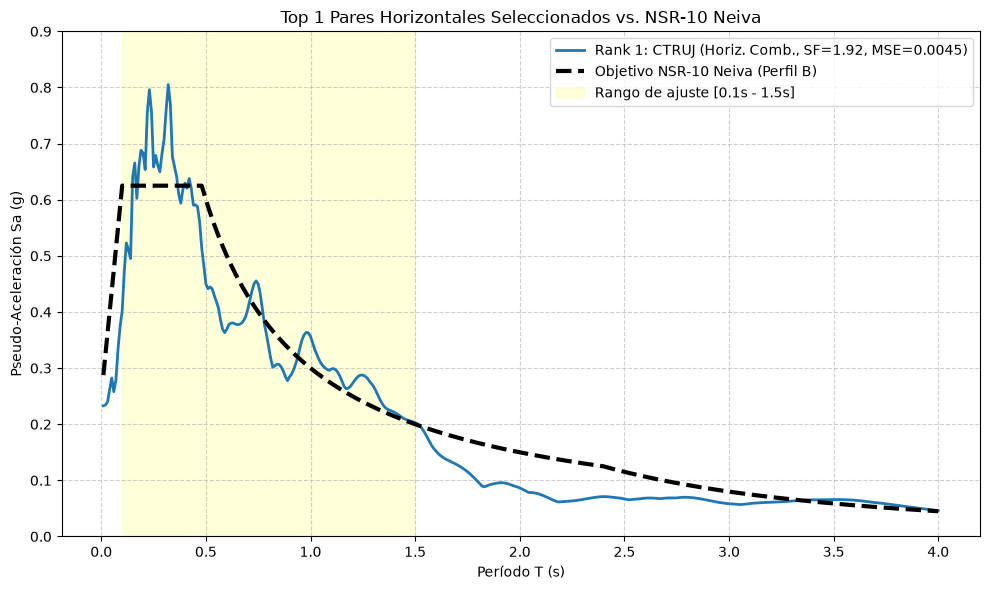


SELECCIÓN DE SISMOS POR PAR HORIZONTAL COMBINADO (CUMPLE NORMATIVA)
 Ranking Estacion_Sismo Canales_Exportados  Factor_Escala_SF  Error_MSE  PGA_Max_H1_g  PGA_Max_H2_g
       1          CTRUJ     ['HNE', 'HNN']             1.924    0.00449         0.197         0.274


In [5]:
import os
import obspy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Detectar función de integración compatible con NumPy 1.x y 2.x
trapezoid_func = getattr(np, 'trapezoid', getattr(np, 'trapz', None))

# =============================================================================
# 1. CONFIGURACIÓN Y CRITERIOS DE SELECCIÓN POR PAR HORIZONTAL
# =============================================================================
ruta_mseed = r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos originales\SGCWaveForm.mseed"
dir_salida = r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos sismo\sismos_horizontales_seleccionados"

os.makedirs(dir_salida, exist_ok=True)

# Estaciones candidatas
estaciones_roca = ["CTRUJ", "PAL", "URE", "RUS", "POP", "ROSC"]

# Parámetros de optimización
T_MIN_PEER, T_MAX_PEER = 0.1, 1.5
SF_MIN, SF_MAX = 0.25, 4.0
NUM_ESTACIONES_A_SELECCIONAR = 3

# =============================================================================
# 2. FUNCIONES MATEMÁTICAS Y ESPECTRALES
# =============================================================================
def normalizar_aceleracion_a_g(tr):
    datos = tr.data.astype(float)
    pga_raw = np.max(np.abs(datos))
    if pga_raw > 1000.0:
        return (datos / 400000.0) / 9.81
    elif pga_raw > 20.0:
        return (datos / 100.0) / 9.81
    elif pga_raw > 1.5:
        return datos / 9.81
    else:
        return datos

def espectro_nsr10_neiva_roca(periodos):
    Aa, Av = 0.25, 0.25
    Fa, Fv = 1.0, 1.0
    T0, TC, TL = 0.10, 0.48, 2.40
    
    Sa_norma = np.zeros(len(periodos))
    for idx, T in enumerate(periodos):
        if T < T0:
            Sa_norma[idx] = Aa * Fa * (1.0 + 1.5 * (T / T0))
        elif T0 <= T <= TC:
            Sa_norma[idx] = 2.5 * Aa * Fa
        elif TC < T <= TL:
            Sa_norma[idx] = (1.2 * Av * Fv) / T
        else:
            Sa_norma[idx] = (1.2 * Av * Fv * TL) / (T**2)
    return Sa_norma

def calcular_espectro_newmark(acc_g, dt, periodos, damping=0.05):
    acc_m_s2 = acc_g * 9.81
    Sa_g = np.zeros(len(periodos))
    gamma, beta = 0.5, 0.25
    N = len(acc_m_s2)

    for idx, T in enumerate(periodos):
        if T <= 0:
            Sa_g[idx] = np.max(np.abs(acc_g))
            continue
        omega = 2.0 * np.pi / T
        m = 1.0
        c = 2.0 * damping * omega * m
        k = (omega ** 2) * m

        k_hat = k + (gamma / (beta * dt)) * c + (1.0 / (beta * dt**2)) * m
        a_const = (1.0 / (beta * dt)) * m + (gamma / beta) * c
        b_const = (1.0 / (2.0 * beta)) * m + dt * ((gamma / (2.0 * beta)) - 1.0) * c

        u, v, a_rel = np.zeros(N), np.zeros(N), np.zeros(N)
        a_rel[0] = -acc_m_s2[0]

        for i in range(N - 1):
            df = -m * (acc_m_s2[i+1] - acc_m_s2[i]) + a_const * v[i] + b_const * a_rel[i]
            du = df / k_hat
            dv = (gamma / (beta * dt)) * du - (gamma / beta) * v[i] + dt * (1.0 - gamma / (2.0 * beta)) * a_rel[i]
            da = (1.0 / (beta * dt**2)) * du - (1.0 / (beta * dt)) * v[i] - (1.0 / (2.0 * beta)) * a_rel[i]
            u[i+1], v[i+1], a_rel[i+1] = u[i] + du, v[i] + dv, a_rel[i] + da

        Sa_m_s2 = (omega ** 2) * np.max(np.abs(u))
        Sa_g[idx] = Sa_m_s2 / 9.81

    return Sa_g

# =============================================================================
# 3. PROCESAMIENTO Y AGRUPAMIENTO POR ESTACIÓN (PARES HORIZONTALES)
# =============================================================================
st = obspy.read(ruta_mseed)
periodos = np.linspace(0.01, 4.0, 400)
Sa_target = espectro_nsr10_neiva_roca(periodos)

# Agrupar trazas únicamente horizontales por estación
estaciones_procesadas = {}

for estacion in estaciones_roca:
    # Filtrar componentes horizontales (HNE, HNN, HHE, HHN, etc.) excluyendo Z
    trazas_horiz = [tr for tr in st if tr.stats.station == estacion 
                    and tr.stats.channel.startswith("HN") 
                    and not tr.stats.channel.endswith("Z")]
    
    if len(trazas_horiz) < 2:
        continue  # Se requiere el par horizontal completo (E y N)

    datos_estacion = {"estacion": estacion, "componentes": {}}

    for tr in trazas_horiz:
        canal = tr.stats.channel
        tr_proc = tr.copy()
        tr_proc.detrend("linear")
        tr_proc.filter("bandpass", freqmin=0.1, freqmax=25.0, corners=4, zerophase=True)

        dt = tr_proc.stats.delta
        acc_g_orig = normalizar_aceleracion_a_g(tr_proc)
        tiempo = np.arange(len(acc_g_orig)) * dt
        Sa_real = calcular_espectro_newmark(acc_g_orig, dt, periodos)

        datos_estacion["componentes"][canal] = {
            "tiempo": tiempo,
            "dt": dt,
            "acc_g_orig": acc_g_orig,
            "Sa_real": Sa_real
        }

    # Calcular la Media Geométrica Espectral del Par Horizontal
    canales = list(datos_estacion["componentes"].keys())
    Sa_h1 = datos_estacion["componentes"][canales[0]]["Sa_real"]
    Sa_h2 = datos_estacion["componentes"][canales[1]]["Sa_real"]
    Sa_geomean = np.sqrt(Sa_h1 * Sa_h2)

    # Optimización PEER sobre la Media Geométrica
    mask = (periodos >= T_MIN_PEER) & (periodos <= T_MAX_PEER)
    SF = np.sum(Sa_target[mask] * Sa_geomean[mask]) / np.sum(Sa_geomean[mask]**2)
    Sa_geomean_escalado = Sa_geomean * SF
    MSE = np.mean((Sa_geomean_escalado[mask] - Sa_target[mask])**2)

    if SF_MIN <= SF <= SF_MAX:
        datos_estacion["SF"] = SF
        datos_estacion["MSE"] = MSE
        datos_estacion["Sa_geomean_escalado"] = Sa_geomean_escalado
        estaciones_procesadas[estacion] = datos_estacion

# =============================================================================
# 4. RANKING Y EXPORTACIÓN DE PARES HORIZONTALES INDEPENDIENTES
# =============================================================================
# Ordenar estaciones de menor a mayor error MSE
estaciones_ordenadas = sorted(estaciones_procesadas.values(), key=lambda x: x["MSE"])
estaciones_top = estaciones_ordenadas[:NUM_ESTACIONES_A_SELECCIONAR]

plt.figure(figsize=(10, 6))
resumen_exportacion = []

for idx, est_data in enumerate(estaciones_top, 1):
    nom_est = est_data["estacion"]
    SF = est_data["SF"]
    MSE = est_data["MSE"]

    # Exportar ambas componentes horizontales escaladas con el mismo SF
    for canal, comp in est_data["componentes"].items():
        acc_escalada = comp["acc_g_orig"] * SF
        df_acc = pd.DataFrame({
            "Tiempo_s": comp["tiempo"],
            "Aceleracion_g": acc_escalada
        })
        archivo_salida = os.path.join(dir_salida, f"Rank{idx}_{nom_est}_{canal}_escalado.csv")
        df_acc.to_csv(archivo_salida, index=False)

    # Graficar la media geométrica espectral del par horizontal
    plt.plot(periodos, est_data["Sa_geomean_escalado"], lw=2.0,
             label=f"Rank {idx}: {nom_est} (Horiz. Comb., SF={SF:.2f}, MSE={MSE:.4f})")

    resumen_exportacion.append({
        "Ranking": idx,
        "Estacion_Sismo": nom_est,
        "Canales_Exportados": f"{list(est_data['componentes'].keys())}",
        "Factor_Escala_SF": round(SF, 3),
        "Error_MSE": round(MSE, 5),
        "PGA_Max_H1_g": round(np.max(np.abs(list(est_data['componentes'].values())[0]['acc_g_orig'] * SF)), 3),
        "PGA_Max_H2_g": round(np.max(np.abs(list(est_data['componentes'].values())[1]['acc_g_orig'] * SF)), 3),
    })

# Decoración del Gráfico
plt.plot(periodos, Sa_target, color="black", lw=3.0, linestyle="--", label="Objetivo NSR-10 Neiva (Perfil B)")
plt.axvspan(T_MIN_PEER, T_MAX_PEER, color='yellow', alpha=0.15, label=f"Rango de ajuste [{T_MIN_PEER}s - {T_MAX_PEER}s]")

plt.title(f"Top {len(estaciones_top)} Pares Horizontales Seleccionados vs. NSR-10 Neiva")
plt.xlabel("Período T (s)")
plt.ylabel("Pseudo-Aceleración Sa (g)")
plt.ylim(0, 0.9)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()

# Guardar figura y reporte
plt.savefig(os.path.join(dir_salida, "Top_Pares_Horizontales_Seleccionados.png"), dpi=300)
plt.show()

df_reporte = pd.DataFrame(resumen_exportacion)
df_reporte.to_csv(os.path.join(dir_salida, "Reporte_Pares_Horizontales.csv"), index=False)

print("\n" + "="*95)
print("SELECCIÓN DE SISMOS POR PAR HORIZONTAL COMBINADO (CUMPLE NORMATIVA)")
print("="*95)
print(df_reporte.to_string(index=False))